In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
wine = load_wine()
X = wine.data

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

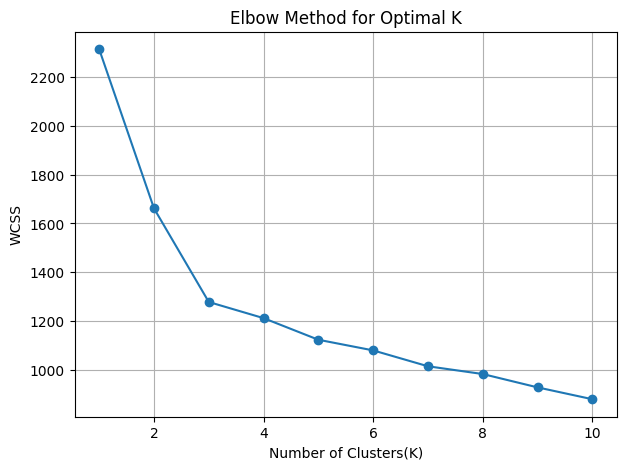

In [6]:
plt.figure(figsize=(7,5))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.grid()
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

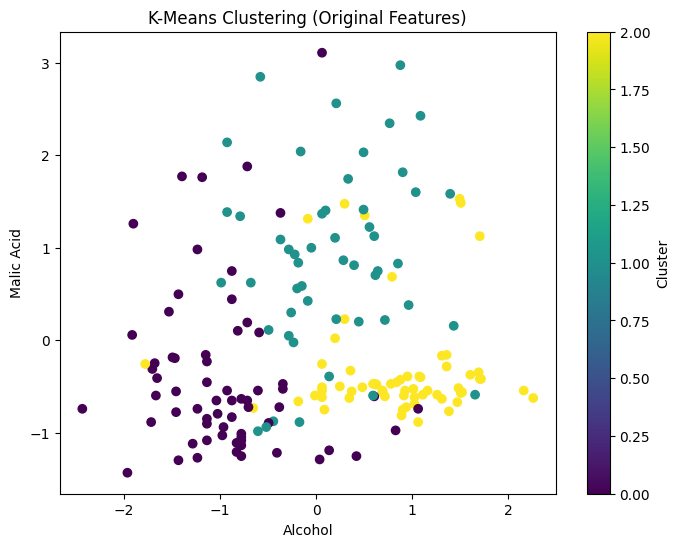

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_scaled[:, 0],    # Alcohol
    X_scaled[:, 1],    # Malic Acid
    c=clusters,
    cmap='viridis'
)

plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.title("K-Means Clustering (Original Features)")
plt.colorbar(label="Cluster")
plt.show()


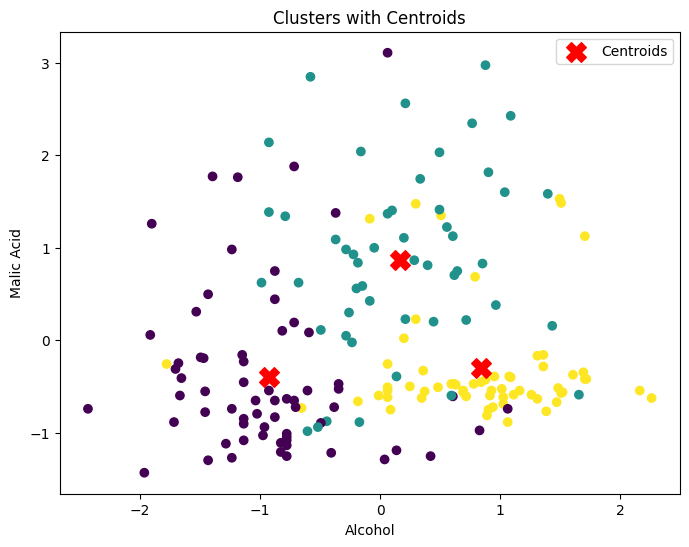

In [19]:
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis')
plt.scatter(
    centroids[:,0],
    centroids[:,1],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel("Alcohol")
plt.ylabel("Malic Acid")
plt.legend()
plt.title("Clusters with Centroids")
plt.show()
